# Accessibility Scene Hazard Assistant

**CSCI435 - Computer Vision Algorithms and Systems**  
**University of Wollongong in Dubai - Spring 2026**

**Group members:** Mehdi Leghmizi (8528834), Neeraj Santosh (8329345), Muhammad Soban (8555588), Zachary Bracke (8947405), and Mostafa Shalash (7391493).

## Problem and user story

People with limited vision may need a fast indication of warnings, safe-route markers, boundaries, and movement in front of a camera. As a user, I want to upload an image or video, or capture a webcam image, so that one interface enhances the scene, recognises marker-like objects, highlights boundaries and movement, and gives concise guidance.

## Integrated permissible capabilities

1. Image enhancement (gray-world colour correction and CLAHE).
2. Edge detection (adaptive Canny and morphology).
3. Object detection (colour segmentation and contour proposals).
4. Object recognition (a custom-trained SVM).
5. Change/background modelling and moving-object detection (MOG2).
6. Object tracking (centroid association across video frames).

The notebook is intentionally self-contained: it generates custom training data, compares models, trains the selected model, evaluates robustness, benchmarks speed, creates demonstration assets, and launches a Gradio web app. Run all cells from top to bottom.


In [1]:
# Dependency bootstrap: packages are installed only when imports are missing.
import importlib.util
import os
import subprocess
import sys

PACKAGE_MAP = {
    "cv2": "opencv-python-headless==4.11.0.86",
    "sklearn": "scikit-learn==1.7.0",
    "matplotlib": "matplotlib==3.10.3",
    "pandas": "pandas==2.3.0",
    "gradio": "gradio==5.34.2",
    "joblib": "joblib==1.5.1",
    "PIL": "Pillow==11.2.1",
}
missing = [package for module, package in PACKAGE_MAP.items() if importlib.util.find_spec(module) is None]
if missing:
    print("Installing missing packages:", ", ".join(missing))
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])
else:
    print("All runtime dependencies are available.")


All runtime dependencies are available.


In [2]:
from __future__ import annotations

import json
import math
import random
import textwrap
import time
import warnings
from collections import OrderedDict
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Iterable

warnings.filterwarnings("ignore", message="IProgress not found.*")
warnings.filterwarnings("ignore", message="Video does not have browser-compatible.*")

import cv2
import gradio as gr
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

SEED = 435
random.seed(SEED)
np.random.seed(SEED)

ROOT = Path.cwd()
ARTIFACTS = ROOT / "artifacts"
DATASET_DIR = ARTIFACTS / "custom_dataset"
ARTIFACTS.mkdir(parents=True, exist_ok=True)
DATASET_DIR.mkdir(parents=True, exist_ok=True)

LABELS = ["stop", "warning", "safe", "other"]
TARGET_LABELS = {"stop", "warning", "safe"}
MAX_WIDTH = 640
MIN_CANDIDATE_AREA = 300

print(f"Python: {sys.version.split()[0]}")
print(f"OpenCV: {cv2.__version__} | scikit-learn model pipeline ready")
print("Artifacts directory: artifacts/")


Python: 3.12.13
OpenCV: 4.11.0 | scikit-learn model pipeline ready
Artifacts directory: artifacts/


## 1. Custom data generation

The brief requires a model trained or fine-tuned on custom data. To make the submission reproducible without private downloads, this notebook generates a labelled dataset of accessibility-style marker crops. The generator varies scale, position, background, rotation, brightness, blur, noise, and partial occlusion. `other` examples act as hard negatives. The synthetic-to-real domain gap is reported as a limitation rather than hidden.


Generated 560 custom labelled images (140 per class).


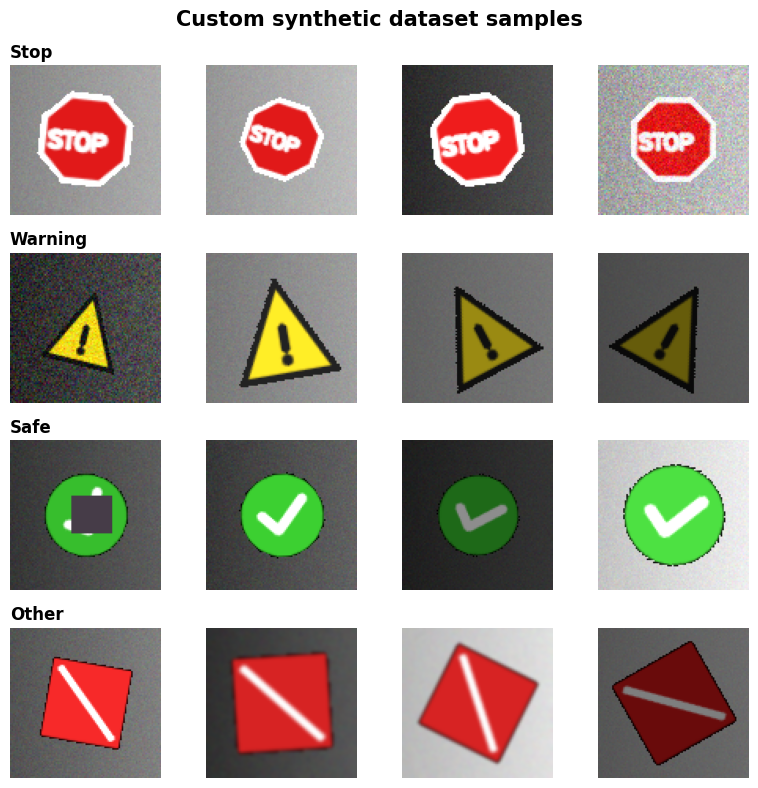

In [3]:
def _marker_geometry(label: str, size: int) -> tuple[np.ndarray, tuple[int, int, int]]:
    '''Return polygon/circle geometry and its BGR colour.'''
    c = size // 2
    radius = int(size * 0.31)
    if label == "stop":
        angles = np.deg2rad(np.arange(22.5, 382.5, 45.0))
        points = np.c_[c + radius * np.cos(angles), c + radius * np.sin(angles)].astype(np.int32)
        return points, (25, 25, 225)
    if label == "warning":
        points = np.array([[c, c - radius], [c - radius, c + radius], [c + radius, c + radius]], np.int32)
        return points, (25, 220, 245)
    if label == "safe":
        return np.array([[c, c, radius]], np.int32), (45, 190, 55)
    points = np.array([[c - radius, c - radius], [c + radius, c - radius], [c + radius, c + radius], [c - radius, c + radius]], np.int32)
    # A red square is a deliberately difficult negative: it passes the colour
    # proposal stage, so the trained recogniser must reject it by shape.
    return points, (35, 35, 215)


def make_marker_patch(
    label: str,
    rng: np.random.Generator,
    size: int = 96,
    condition: str = "mixed",
) -> tuple[np.ndarray, np.ndarray]:
    '''Create one BGR training crop and a visible-object mask.'''
    if label not in LABELS:
        raise ValueError(f"Unknown label: {label}")

    base_level = int(rng.integers(45, 210))
    background = np.full((size, size, 3), base_level, np.uint8)
    gradient = np.linspace(-20, 20, size, dtype=np.float32)[None, :, None]
    background = np.clip(background.astype(np.float32) + gradient, 0, 255).astype(np.uint8)
    background = np.clip(background.astype(np.int16) + rng.normal(0, 5, background.shape), 0, 255).astype(np.uint8)

    layer = np.zeros_like(background)
    mask = np.zeros((size, size), np.uint8)
    geometry, colour = _marker_geometry(label, size)
    if label == "safe":
        c, _, radius = geometry[0]
        cv2.circle(layer, (int(c), int(c)), int(radius), colour, -1, cv2.LINE_AA)
        cv2.circle(mask, (int(c), int(c)), int(radius), 255, -1, cv2.LINE_AA)
        cv2.line(layer, (int(c - radius * 0.5), int(c)), (int(c - radius * 0.1), int(c + radius * 0.4)), (255, 255, 255), 5, cv2.LINE_AA)
        cv2.line(layer, (int(c - radius * 0.1), int(c + radius * 0.4)), (int(c + radius * 0.55), int(c - radius * 0.4)), (255, 255, 255), 5, cv2.LINE_AA)
    else:
        cv2.fillPoly(layer, [geometry], colour, cv2.LINE_AA)
        cv2.fillPoly(mask, [geometry], 255, cv2.LINE_AA)
        if label == "stop":
            cv2.polylines(layer, [geometry], True, (255, 255, 255), 3, cv2.LINE_AA)
            cv2.putText(layer, "STOP", (size // 2 - 23, size // 2 + 6), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255, 255, 255), 2, cv2.LINE_AA)
        elif label == "warning":
            cv2.polylines(layer, [geometry], True, (20, 20, 20), 3, cv2.LINE_AA)
            cv2.putText(layer, "!", (size // 2 - 5, size // 2 + 20), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (20, 20, 20), 3, cv2.LINE_AA)
        else:
            cv2.line(layer, (25, 25), (71, 71), (255, 255, 255), 4, cv2.LINE_AA)

    angle_ranges = {"rotated": (-55, 55), "mixed": (-35, 35)}
    lo, hi = angle_ranges.get(condition, (-12, 12))
    angle = float(rng.uniform(lo, hi))
    scale = float(rng.uniform(0.78, 1.08))
    matrix = cv2.getRotationMatrix2D((size / 2, size / 2), angle, scale)
    layer = cv2.warpAffine(layer, matrix, (size, size), flags=cv2.INTER_LINEAR, borderValue=(0, 0, 0))
    mask = cv2.warpAffine(mask, matrix, (size, size), flags=cv2.INTER_NEAREST, borderValue=0)
    visible = mask > 0
    patch = background.copy()
    patch[visible] = layer[visible]

    if condition == "mixed":
        condition = rng.choice(["bright", "dim", "rotated", "blurred", "noisy", "occluded"], p=[0.25, 0.2, 0.15, 0.12, 0.15, 0.13])
    if condition == "bright":
        patch = cv2.convertScaleAbs(patch, alpha=float(rng.uniform(1.0, 1.25)), beta=int(rng.integers(0, 18)))
    elif condition == "dim":
        patch = cv2.convertScaleAbs(patch, alpha=float(rng.uniform(0.38, 0.62)), beta=int(rng.integers(-8, 4)))
    elif condition == "blurred":
        patch = cv2.GaussianBlur(patch, (5, 5), float(rng.uniform(0.8, 1.6)))
    elif condition == "noisy":
        noise = rng.normal(0, 18, patch.shape)
        patch = np.clip(patch.astype(np.float32) + noise, 0, 255).astype(np.uint8)
    elif condition == "occluded":
        x1 = int(rng.integers(size // 4, size // 2))
        y1 = int(rng.integers(size // 4, size // 2))
        x2 = min(size, x1 + int(rng.integers(size // 6, size // 3)))
        y2 = min(size, y1 + int(rng.integers(size // 8, size // 4)))
        colour_bg = tuple(int(v) for v in background[y1, x1])
        cv2.rectangle(patch, (x1, y1), (x2, y2), colour_bg, -1)
        cv2.rectangle(mask, (x1, y1), (x2, y2), 0, -1)

    return patch, mask


def build_custom_dataset(per_class: int = 140) -> tuple[list[np.ndarray], list[np.ndarray], np.ndarray]:
    images: list[np.ndarray] = []
    masks: list[np.ndarray] = []
    labels: list[str] = []
    for label_index, label in enumerate(LABELS):
        class_dir = DATASET_DIR / label
        class_dir.mkdir(parents=True, exist_ok=True)
        rng = np.random.default_rng(SEED + label_index * 1000)
        for index in range(per_class):
            patch, mask = make_marker_patch(label, rng, condition="mixed")
            images.append(patch)
            masks.append(mask)
            labels.append(label)
            cv2.imwrite(str(class_dir / f"{label}_{index:03d}.png"), patch)
    return images, masks, np.asarray(labels)


images, masks, y = build_custom_dataset()
print(f"Generated {len(images)} custom labelled images ({len(images) // len(LABELS)} per class).")

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for row, label in enumerate(LABELS):
    indices = np.where(y == label)[0][:4]
    for col, index in enumerate(indices):
        axes[row, col].imshow(cv2.cvtColor(images[index], cv2.COLOR_BGR2RGB))
        axes[row, col].axis("off")
        if col == 0:
            axes[row, col].set_title(label.title(), loc="left", fontweight="bold")
fig.suptitle("Custom synthetic dataset samples", fontsize=15, fontweight="bold")
fig.tight_layout()
fig.savefig(ARTIFACTS / "dataset_montage.png", dpi=180, bbox_inches="tight")
plt.show()


## 2. Feature extraction, model selection, and training

Each crop is represented by HOG edge/shape features, HSV colour histograms, grayscale statistics, and Hu moments. Three compact classifiers are evaluated on the same stratified 75/25 split. The RBF SVM is selected when its accuracy is within one percentage point of the best candidate because it gives a smooth non-linear decision boundary and a compact inference path.


,model,validation_accuracy,training_seconds,inference_ms_per_crop
0,SVM (RBF),1.000,0.105,0.070
1,Random forest,1.000,0.168,0.193
2,k-NN,1.000,0.005,9.172


Selected model: SVM (RBF) | held-out accuracy: 1.000
              precision    recall  f1-score   support

        stop       1.00      1.00      1.00        35
     warning       1.00      1.00      1.00        35
        safe       1.00      1.00      1.00        35
       other       1.00      1.00      1.00        35

    accuracy                           1.00       140
   macro avg       1.00      1.00      1.00       140
weighted avg       1.00      1.00      1.00       140



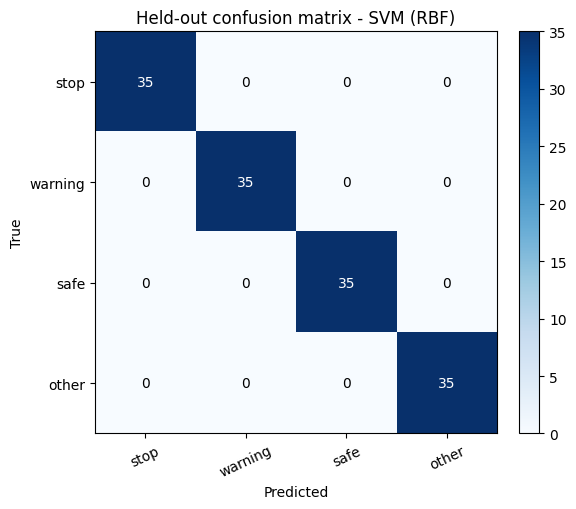

In [4]:
HOG = cv2.HOGDescriptor((48, 48), (16, 16), (8, 8), (8, 8), 9)


def canonicalise_marker(
    patch_bgr: np.ndarray,
    foreground_mask: np.ndarray,
    canvas_size: int = 96,
    object_size: int = 62,
) -> np.ndarray:
    '''Centre a segmented candidate at the same scale used for training and inference.'''
    if patch_bgr is None or patch_bgr.size == 0 or foreground_mask is None or foreground_mask.size == 0:
        raise ValueError("Canonicalisation received an empty image or mask.")
    binary = (foreground_mask > 0).astype(np.uint8)
    points = cv2.findNonZero(binary)
    if points is None:
        raise ValueError("Canonicalisation requires at least one foreground pixel.")
    x, y, w, h = cv2.boundingRect(points)
    object_crop = patch_bgr[y : y + h, x : x + w]
    mask_crop = binary[y : y + h, x : x + w]
    scale = object_size / max(w, h)
    new_w, new_h = max(1, int(round(w * scale))), max(1, int(round(h * scale)))
    interpolation = cv2.INTER_AREA if scale < 1 else cv2.INTER_LINEAR
    object_crop = cv2.resize(object_crop, (new_w, new_h), interpolation=interpolation)
    mask_crop = cv2.resize(mask_crop, (new_w, new_h), interpolation=cv2.INTER_NEAREST)
    canvas = np.full((canvas_size, canvas_size, 3), 128, np.uint8)
    x0, y0 = (canvas_size - new_w) // 2, (canvas_size - new_h) // 2
    region = canvas[y0 : y0 + new_h, x0 : x0 + new_w]
    region[mask_crop > 0] = object_crop[mask_crop > 0]
    return canvas


def extract_features(patch_bgr: np.ndarray) -> np.ndarray:
    if patch_bgr is None or patch_bgr.size == 0:
        raise ValueError("Feature extraction received an empty image.")
    patch = cv2.resize(patch_bgr, (48, 48), interpolation=cv2.INTER_AREA)
    gray = cv2.cvtColor(patch, cv2.COLOR_BGR2GRAY)
    hsv = cv2.cvtColor(patch, cv2.COLOR_BGR2HSV)
    hog = HOG.compute(gray).ravel()
    h_hist = cv2.calcHist([hsv], [0], None, [18], [0, 180]).ravel()
    s_hist = cv2.calcHist([hsv], [1], None, [12], [0, 256]).ravel()
    h_hist /= h_hist.sum() + 1e-6
    s_hist /= s_hist.sum() + 1e-6
    _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    hu = cv2.HuMoments(cv2.moments(binary)).ravel()
    hu = -np.sign(hu) * np.log10(np.abs(hu) + 1e-12)
    stats = np.array([gray.mean(), gray.std(), hsv[..., 1].mean(), hsv[..., 2].mean()], dtype=np.float32) / 255.0
    return np.concatenate([hog, h_hist, s_hist, hu, stats]).astype(np.float32)


X = np.vstack([extract_features(canonicalise_marker(image, mask)) for image, mask in zip(images, masks)])
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=SEED, stratify=y
)

candidate_models = OrderedDict(
    {
        "SVM (RBF)": Pipeline(
            [("scale", StandardScaler()), ("model", SVC(C=6.0, gamma="scale", probability=True, class_weight="balanced", random_state=SEED))]
        ),
        "Random forest": RandomForestClassifier(
            n_estimators=180, min_samples_leaf=2, class_weight="balanced", n_jobs=-1, random_state=SEED
        ),
        "k-NN": Pipeline(
            [("scale", StandardScaler()), ("model", KNeighborsClassifier(n_neighbors=7, weights="distance"))]
        ),
    }
)

comparison_rows = []
fitted_models = {}
for name, estimator in candidate_models.items():
    start = time.perf_counter()
    estimator.fit(X_train, y_train)
    training_seconds = time.perf_counter() - start
    start = time.perf_counter()
    prediction = estimator.predict(X_test)
    inference_ms = (time.perf_counter() - start) * 1000 / len(X_test)
    accuracy = accuracy_score(y_test, prediction)
    comparison_rows.append(
        {"model": name, "validation_accuracy": accuracy, "training_seconds": training_seconds, "inference_ms_per_crop": inference_ms}
    )
    fitted_models[name] = estimator

comparison = pd.DataFrame(comparison_rows).sort_values(["validation_accuracy", "inference_ms_per_crop"], ascending=[False, True])
best_accuracy = comparison["validation_accuracy"].max()
selected_model_name = "SVM (RBF)" if float(comparison.loc[comparison.model == "SVM (RBF)", "validation_accuracy"].iloc[0]) >= best_accuracy - 0.01 else str(comparison.iloc[0].model)
classifier = fitted_models[selected_model_name]
test_predictions = classifier.predict(X_test)
test_accuracy = float(accuracy_score(y_test, test_predictions))

comparison.to_csv(ARTIFACTS / "model_comparison.csv", index=False)
joblib.dump(classifier, ARTIFACTS / "custom_marker_classifier.joblib")
display(comparison.style.format({"validation_accuracy": "{:.3f}", "training_seconds": "{:.3f}", "inference_ms_per_crop": "{:.3f}"}))
print(f"Selected model: {selected_model_name} | held-out accuracy: {test_accuracy:.3f}")
print(classification_report(y_test, test_predictions, labels=LABELS, zero_division=0))

cm = confusion_matrix(y_test, test_predictions, labels=LABELS)
fig, ax = plt.subplots(figsize=(6.4, 5.2))
image = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(LABELS)), LABELS, rotation=25)
ax.set_yticks(range(len(LABELS)), LABELS)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title(f"Held-out confusion matrix - {selected_model_name}")
for i in range(len(LABELS)):
    for j in range(len(LABELS)):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center", color="white" if cm[i, j] > cm.max() / 2 else "black")
fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
fig.savefig(ARTIFACTS / "confusion_matrix.png", dpi=180, bbox_inches="tight")
plt.show()


## 3. Integrated frame-processing system

The functions below are the application backend. They validate and resize input, enhance the frame, compute edges, propose and classify marker regions, model motion, track moving regions, fuse the outputs, and measure latency. A single `VisionSystem` object is used by both image and video modes.


In [5]:
@dataclass
class MarkerDetection:
    label: str
    confidence: float
    box: tuple[int, int, int, int]


@dataclass
class FrameResult:
    annotated: np.ndarray
    enhanced: np.ndarray
    edge_view: np.ndarray
    edge_mask: np.ndarray
    detections: list[MarkerDetection]
    motion_boxes: list[tuple[int, int, int, int]]
    summary: str
    latency_ms: float
    fps: float


def validate_and_resize(frame_bgr: np.ndarray, max_width: int = MAX_WIDTH) -> np.ndarray:
    if frame_bgr is None or not isinstance(frame_bgr, np.ndarray) or frame_bgr.size == 0:
        raise ValueError("Please provide a non-empty image or readable video frame.")
    if frame_bgr.ndim == 2:
        frame_bgr = cv2.cvtColor(frame_bgr, cv2.COLOR_GRAY2BGR)
    if frame_bgr.ndim != 3 or frame_bgr.shape[2] not in (3, 4):
        raise ValueError("Input must be a grayscale, RGB, RGBA, or BGR image.")
    if frame_bgr.shape[2] == 4:
        frame_bgr = cv2.cvtColor(frame_bgr, cv2.COLOR_BGRA2BGR)
    height, width = frame_bgr.shape[:2]
    if min(height, width) < 32:
        raise ValueError("Input is too small; both dimensions must be at least 32 pixels.")
    if width > max_width:
        scale = max_width / width
        frame_bgr = cv2.resize(frame_bgr, (max_width, max(32, int(height * scale))), interpolation=cv2.INTER_AREA)
    return np.ascontiguousarray(frame_bgr.astype(np.uint8))


def enhance_image(frame_bgr: np.ndarray) -> np.ndarray:
    image = frame_bgr.astype(np.float32)
    channel_means = image.reshape(-1, 3).mean(axis=0)
    target = channel_means.mean()
    scales = np.clip(target / (channel_means + 1e-6), 0.72, 1.28)
    balanced = np.clip(image * scales, 0, 255).astype(np.uint8)
    lab = cv2.cvtColor(balanced, cv2.COLOR_BGR2LAB)
    l_channel, a_channel, b_channel = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.2, tileGridSize=(8, 8))
    enhanced_l = clahe.apply(l_channel)
    return cv2.cvtColor(cv2.merge([enhanced_l, a_channel, b_channel]), cv2.COLOR_LAB2BGR)


def adaptive_canny(frame_bgr: np.ndarray) -> np.ndarray:
    gray = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    median = float(np.median(blurred))
    low = int(max(20, 0.66 * median))
    high = int(min(240, max(low + 30, 1.33 * median)))
    edges = cv2.Canny(blurred, low, high)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    return cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel)


def create_edge_view(frame_bgr: np.ndarray, edges: np.ndarray) -> np.ndarray:
    overlay = frame_bgr.copy()
    overlay[edges > 0] = (70, 255, 80)
    return cv2.addWeighted(frame_bgr, 0.70, overlay, 0.30, 0)


def colour_candidate_masks(frame_bgr: np.ndarray) -> dict[str, np.ndarray]:
    '''Return separate colour masks so neighbouring marker colours cannot merge.''' 
    hsv = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2HSV)
    red = cv2.inRange(hsv, (0, 70, 45), (12, 255, 255)) | cv2.inRange(hsv, (168, 70, 45), (180, 255, 255))
    yellow = cv2.inRange(hsv, (16, 65, 55), (42, 255, 255))
    green = cv2.inRange(hsv, (38, 45, 35), (96, 255, 255))
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    masks = {}
    for name, mask in {"red": red, "yellow": yellow, "green": green}.items():
        cleaned = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
        masks[name] = cv2.morphologyEx(cleaned, cv2.MORPH_CLOSE, kernel, iterations=2)
    return masks


def colour_candidate_mask(frame_bgr: np.ndarray) -> np.ndarray:
    masks = colour_candidate_masks(frame_bgr)
    return masks["red"] | masks["yellow"] | masks["green"]


def shape_colour_hint(
    source_bgr: np.ndarray,
    contour: np.ndarray,
    colour_name: str,
) -> tuple[str, float] | None:
    '''Recognise canonical marker geometry when the learned crop model is uncertain.'''
    area = float(cv2.contourArea(contour))
    perimeter = float(cv2.arcLength(contour, True))
    if area <= 0 or perimeter <= 0:
        return None
    x, y, width, height = cv2.boundingRect(contour)
    ratio = width / max(height, 1)
    circularity = float(4 * np.pi * area / (perimeter * perimeter))
    extent = area / max(width * height, 1)
    vertices = len(cv2.approxPolyDP(contour, 0.035 * perimeter, True))

    # A filled outer contour includes white/bright symbols that are holes in the
    # colour mask (STOP lettering, border, or a check mark).
    filled = np.zeros(source_bgr.shape[:2], np.uint8)
    cv2.drawContours(filled, [contour], -1, 255, -1)
    hsv = cv2.cvtColor(source_bgr, cv2.COLOR_BGR2HSV)
    inside = filled > 0
    light_symbol_fraction = float(np.mean((hsv[..., 1][inside] < 85) & (hsv[..., 2][inside] > 145))) if np.any(inside) else 0.0

    if colour_name == "green" and 0.72 <= ratio <= 1.38 and circularity >= 0.66 and vertices >= 7 and light_symbol_fraction >= 0.015:
        confidence = min(0.98, 0.58 + 0.30 * circularity + min(light_symbol_fraction, 0.20))
        return "safe", confidence
    if colour_name == "yellow" and 0.60 <= ratio <= 1.55 and 3 <= vertices <= 6 and 0.32 <= extent <= 0.72:
        confidence = min(0.96, 0.66 + 0.04 * (6 - abs(vertices - 3)))
        return "warning", confidence
    if colour_name == "red" and 0.72 <= ratio <= 1.38 and 6 <= vertices <= 12 and circularity >= 0.62 and light_symbol_fraction >= 0.015:
        confidence = min(0.98, 0.60 + 0.28 * circularity + min(light_symbol_fraction, 0.18))
        return "stop", confidence
    return None


def box_iou(box_a: tuple[int, int, int, int], box_b: tuple[int, int, int, int]) -> float:
    x1, y1 = max(box_a[0], box_b[0]), max(box_a[1], box_b[1])
    x2, y2 = min(box_a[2], box_b[2]), min(box_a[3], box_b[3])
    intersection = max(0, x2 - x1) * max(0, y2 - y1)
    area_a = max(0, box_a[2] - box_a[0]) * max(0, box_a[3] - box_a[1])
    area_b = max(0, box_b[2] - box_b[0]) * max(0, box_b[3] - box_b[1])
    return intersection / max(area_a + area_b - intersection, 1)


def detect_markers(
    frame_bgr: np.ndarray,
    model,
    confidence_threshold: float = 0.45,
    classification_frame: np.ndarray | None = None,
) -> list[MarkerDetection]:
    '''Fuse SVM probabilities with colour/shape evidence from original and enhanced pixels.'''
    height, width = frame_bgr.shape[:2]
    source = frame_bgr if classification_frame is None else classification_frame
    if source.shape[:2] != frame_bgr.shape[:2]:
        raise ValueError("Proposal and classification frames must have the same dimensions.")
    candidates: list[MarkerDetection] = []

    # Original pixels prevent gray-world colour shifts on single-colour images;
    # enhanced pixels retain the low-light benefit. Duplicates are suppressed later.
    proposal_frames = [source]
    if not np.shares_memory(source, frame_bgr):
        proposal_frames.append(frame_bgr)
    for proposal_frame in proposal_frames:
        for colour_name, mask in colour_candidate_masks(proposal_frame).items():
            contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            for contour in contours:
                area = cv2.contourArea(contour)
                if area < MIN_CANDIDATE_AREA:
                    continue
                x, y, w, h = cv2.boundingRect(contour)
                if not 0.38 <= w / max(h, 1) <= 2.6 or w < 14 or h < 14:
                    continue
                pad = max(4, int(0.18 * max(w, h)))
                x1, y1 = max(0, x - pad), max(0, y - pad)
                x2, y2 = min(width, x + w + pad), min(height, y + h + pad)
                canonical = canonicalise_marker(source[y1:y2, x1:x2], mask[y1:y2, x1:x2])
                probabilities = model.predict_proba(extract_features(canonical).reshape(1, -1))[0]
                scores = {str(label): float(score) for label, score in zip(model.classes_, probabilities)}
                svm_label = max(scores, key=scores.get)
                label, confidence = svm_label, scores[svm_label]

                hint = shape_colour_hint(source, contour, colour_name)
                if hint is not None:
                    hint_label, hint_confidence = hint
                    # The learned probability still contributes, but a strong
                    # canonical marker shape can recover real-style domain shifts.
                    confidence = max(hint_confidence, 0.70 * hint_confidence + 0.30 * scores.get(hint_label, 0.0))
                    label = hint_label
                if label in TARGET_LABELS and confidence >= confidence_threshold:
                    candidates.append(MarkerDetection(label, confidence, (x, y, x + w, y + h)))

    detections: list[MarkerDetection] = []
    for candidate in sorted(candidates, key=lambda item: item.confidence, reverse=True):
        if any(candidate.label == kept.label and box_iou(candidate.box, kept.box) >= 0.45 for kept in detections):
            continue
        detections.append(candidate)
    return detections


class CentroidTracker:
    def __init__(self, max_distance: float = 80.0, max_missing: int = 8):
        self.max_distance = max_distance
        self.max_missing = max_missing
        self.next_id = 1
        self.objects: dict[int, tuple[int, int]] = {}
        self.missing: dict[int, int] = {}

    def update(self, boxes: list[tuple[int, int, int, int]]) -> list[tuple[int, tuple[int, int, int, int]]]:
        centers = [((x1 + x2) // 2, (y1 + y2) // 2) for x1, y1, x2, y2 in boxes]
        assigned: list[tuple[int, tuple[int, int, int, int]]] = []
        unused_ids = set(self.objects)
        for box, center in zip(boxes, centers):
            if unused_ids:
                distances = {object_id: math.dist(center, self.objects[object_id]) for object_id in unused_ids}
                object_id, distance = min(distances.items(), key=lambda item: item[1])
            else:
                object_id, distance = -1, float("inf")
            if distance <= self.max_distance:
                unused_ids.remove(object_id)
            else:
                object_id = self.next_id
                self.next_id += 1
            self.objects[object_id] = center
            self.missing[object_id] = 0
            assigned.append((object_id, box))
        for object_id in list(self.objects):
            if object_id not in {item[0] for item in assigned}:
                self.missing[object_id] = self.missing.get(object_id, 0) + 1
                if self.missing[object_id] > self.max_missing:
                    self.objects.pop(object_id, None)
                    self.missing.pop(object_id, None)
        return assigned


class MotionDetector:
    def __init__(self):
        self.subtractor = cv2.createBackgroundSubtractorMOG2(history=160, varThreshold=28, detectShadows=True)
        self.tracker = CentroidTracker()
        self.frames_seen = 0

    def update(self, frame_bgr: np.ndarray) -> tuple[np.ndarray, list[tuple[int, tuple[int, int, int, int]]]]:
        self.frames_seen += 1
        mask = self.subtractor.apply(frame_bgr)
        _, mask = cv2.threshold(mask, 220, 255, cv2.THRESH_BINARY)
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
        mask = cv2.dilate(mask, kernel, iterations=2)
        boxes: list[tuple[int, int, int, int]] = []
        if self.frames_seen > 4:
            contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            frame_area = frame_bgr.shape[0] * frame_bgr.shape[1]
            for contour in contours:
                area = cv2.contourArea(contour)
                if 500 <= area <= 0.65 * frame_area:
                    x, y, w, h = cv2.boundingRect(contour)
                    boxes.append((x, y, x + w, y + h))
        return mask, self.tracker.update(boxes)


def horizontal_position(box: tuple[int, int, int, int], width: int) -> str:
    center = (box[0] + box[2]) / 2
    return "left" if center < width / 3 else "centre" if center < 2 * width / 3 else "right"


def build_guidance(detections: list[MarkerDetection], tracked_motion, width: int) -> str:
    instructions = {"stop": "Stop marker", "warning": "Warning marker", "safe": "Safe-route marker"}
    phrases = [f"{instructions[d.label]} on the {horizontal_position(d.box, width)} ({d.confidence:.0%} confidence)" for d in detections[:6]]
    if tracked_motion:
        phrases.append(f"{len(tracked_motion)} moving region(s) tracked")
    return "; ".join(phrases) + "." if phrases else "No accessibility marker or moving region detected."


class VisionSystem:
    def __init__(self, model):
        self.model = model

    def process_frame(self, frame_bgr: np.ndarray, motion: MotionDetector | None = None) -> FrameResult:
        start = time.perf_counter()
        frame = validate_and_resize(frame_bgr)
        enhanced = enhance_image(frame)
        edges = adaptive_canny(enhanced)
        edge_view = create_edge_view(enhanced, edges)
        # Enhancement improves colour proposals, while the unmodified validated
        # frame preserves the appearance distribution learned during training.
        detections = detect_markers(enhanced, self.model, classification_frame=frame)
        annotated = enhanced.copy()
        colours = {"stop": (30, 30, 240), "warning": (20, 190, 245), "safe": (50, 200, 70)}
        for detection in detections:
            x1, y1, x2, y2 = detection.box
            colour = colours[detection.label]
            cv2.rectangle(annotated, (x1, y1), (x2, y2), colour, 2)
            cv2.putText(annotated, f"{detection.label.upper()} {detection.confidence:.2f}", (x1, max(20, y1 - 7)), cv2.FONT_HERSHEY_SIMPLEX, 0.52, colour, 2, cv2.LINE_AA)
        tracked_motion = []
        if motion is not None:
            _, tracked_motion = motion.update(enhanced)
            for object_id, (x1, y1, x2, y2) in tracked_motion:
                cv2.rectangle(annotated, (x1, y1), (x2, y2), (255, 100, 60), 2)
                cv2.putText(annotated, f"MOVING ID {object_id}", (x1, min(annotated.shape[0] - 8, y2 + 18)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 100, 60), 2, cv2.LINE_AA)
        latency_ms = (time.perf_counter() - start) * 1000
        return FrameResult(
            annotated=annotated,
            enhanced=enhanced,
            edge_view=edge_view,
            edge_mask=edges,
            detections=detections,
            motion_boxes=[item[1] for item in tracked_motion],
            summary=build_guidance(detections, tracked_motion, annotated.shape[1]),
            latency_ms=latency_ms,
            fps=1000.0 / max(latency_ms, 1e-6),
        )


SYSTEM = VisionSystem(classifier)
print("Integrated VisionSystem created successfully.")


Integrated VisionSystem created successfully.


## 4. Test scenes, quantitative evaluation, and robustness

The evaluation separates crop-level recognition from end-to-end scene detection. Condition-specific tests use seeds not used for training. End-to-end matching is class-aware and requires intersection-over-union (IoU) of at least 0.30. This section also exercises blank and very small inputs so edge-case behaviour is visible.


,condition,precision,recall,f1,mean_iou,recognition_accuracy
0,bright,1.000,1.000,1.000,0.765,1.000
1,dim,0.955,0.875,0.913,0.727,1.000
2,rotated,1.000,1.000,1.000,0.770,0.943
3,blurred,1.000,1.000,1.000,0.803,1.000
4,noisy,1.000,1.000,1.000,0.752,1.000
5,occluded,0.950,0.792,0.864,0.724,1.000
6,cluttered,0.605,0.958,0.742,0.750,nan


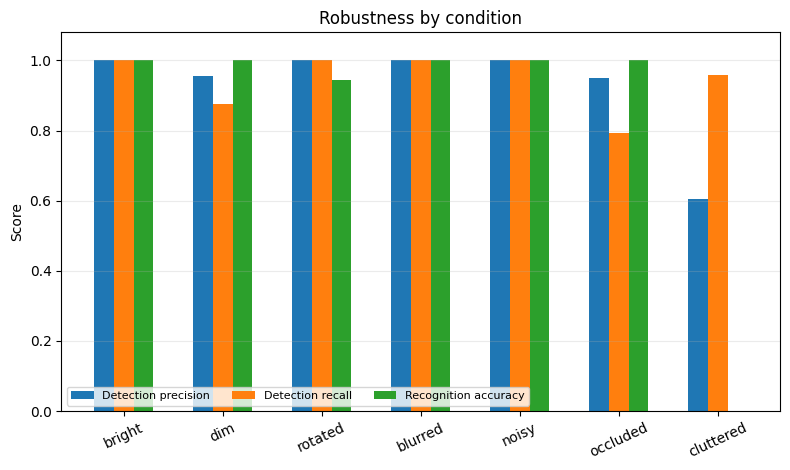

Edge-case tests passed: blank scenes are handled and tiny invalid inputs are rejected.
Real-style regression checks: {
  "stop": {
    "available": true,
    "detected": true,
    "confidence": 0.98,
    "box": [
      158,
      67,
      422,
      314
    ]
  },
  "safe": {
    "available": true,
    "detected": true,
    "confidence": 0.9462410900469063,
    "box": [
      0,
      0,
      640,
      620
    ]
  }
}


In [6]:
def make_scene(condition: str = "bright", seed: int = 100, labels: Iterable[str] = ("stop", "warning", "safe")):
    rng = np.random.default_rng(seed)
    height, width = 480, 640
    scene = np.zeros((height, width, 3), np.uint8)
    for row in range(height):
        value = int(70 + 95 * row / height)
        scene[row, :] = (value, min(255, value + 8), min(255, value + 15))
    cv2.line(scene, (80, height), (250, 180), (200, 200, 200), 4)
    cv2.line(scene, (560, height), (390, 180), (200, 200, 200), 4)
    cv2.rectangle(scene, (255, 170), (385, 390), (110, 100, 85), -1)
    cv2.rectangle(scene, (278, 205), (362, 390), (55, 50, 45), -1)
    if condition == "cluttered":
        for _ in range(35):
            x, y = int(rng.integers(0, width)), int(rng.integers(0, height))
            colour = tuple(int(v) for v in rng.integers(25, 230, 3))
            cv2.circle(scene, (x, y), int(rng.integers(3, 13)), colour, -1)

    positions = [(40, 65), (270, 40), (485, 235)]
    ground_truth = []
    marker_condition = condition if condition in {"bright", "dim", "rotated", "blurred", "noisy", "occluded"} else "bright"
    for index, label in enumerate(labels):
        patch, mask = make_marker_patch(label, rng, size=110, condition=marker_condition)
        x, y = positions[index % len(positions)]
        roi = scene[y : y + patch.shape[0], x : x + patch.shape[1]]
        visible = mask > 0
        roi[visible] = patch[visible]
        ys, xs = np.where(visible)
        if len(xs):
            ground_truth.append({"label": label, "box": (x + int(xs.min()), y + int(ys.min()), x + int(xs.max()) + 1, y + int(ys.max()) + 1)})

    if condition == "dim":
        scene = cv2.convertScaleAbs(scene, alpha=0.55, beta=-8)
    elif condition == "blurred":
        scene = cv2.GaussianBlur(scene, (5, 5), 1.2)
    elif condition == "noisy":
        scene = np.clip(scene.astype(np.float32) + rng.normal(0, 13, scene.shape), 0, 255).astype(np.uint8)
    return scene, ground_truth


def iou(box_a, box_b) -> float:
    x1, y1 = max(box_a[0], box_b[0]), max(box_a[1], box_b[1])
    x2, y2 = min(box_a[2], box_b[2]), min(box_a[3], box_b[3])
    intersection = max(0, x2 - x1) * max(0, y2 - y1)
    area_a = max(0, box_a[2] - box_a[0]) * max(0, box_a[3] - box_a[1])
    area_b = max(0, box_b[2] - box_b[0]) * max(0, box_b[3] - box_b[1])
    return intersection / max(area_a + area_b - intersection, 1)


def evaluate_detection(condition: str, scenes: int = 12) -> dict:
    true_positive = false_positive = false_negative = 0
    matched_ious = []
    for index in range(scenes):
        labels = LABELS[: 1 + (index % 3)]
        scene, truth = make_scene(condition, seed=9000 + index * 13, labels=labels)
        predicted = SYSTEM.process_frame(scene).detections
        used = set()
        for detection in predicted:
            matches = [
                (truth_index, iou(detection.box, item["box"]))
                for truth_index, item in enumerate(truth)
                if truth_index not in used and item["label"] == detection.label
            ]
            if matches:
                truth_index, overlap = max(matches, key=lambda pair: pair[1])
            else:
                truth_index, overlap = -1, 0.0
            if overlap >= 0.30:
                true_positive += 1
                used.add(truth_index)
                matched_ious.append(overlap)
            else:
                false_positive += 1
        false_negative += len(truth) - len(used)
    precision = true_positive / max(true_positive + false_positive, 1)
    recall = true_positive / max(true_positive + false_negative, 1)
    return {
        "condition": condition,
        "precision": precision,
        "recall": recall,
        "f1": 2 * precision * recall / max(precision + recall, 1e-9),
        "mean_iou": float(np.mean(matched_ious)) if matched_ious else 0.0,
    }


conditions = ["bright", "dim", "rotated", "blurred", "noisy", "occluded"]
recognition_rows = []
for condition_index, condition in enumerate(conditions):
    truth, prediction = [], []
    rng = np.random.default_rng(20000 + condition_index)
    for label in LABELS:
        for _ in range(35):
            patch, mask = make_marker_patch(label, rng, condition=condition)
            truth.append(label)
            canonical = canonicalise_marker(patch, mask)
            prediction.append(str(classifier.predict(extract_features(canonical).reshape(1, -1))[0]))
    recognition_rows.append({"condition": condition, "recognition_accuracy": accuracy_score(truth, prediction)})

recognition_robustness = pd.DataFrame(recognition_rows)
detection_robustness = pd.DataFrame([evaluate_detection(condition) for condition in conditions + ["cluttered"]])
robustness = detection_robustness.merge(recognition_robustness, on="condition", how="left")
robustness.to_csv(ARTIFACTS / "robustness_results.csv", index=False)
display(robustness.style.format({column: "{:.3f}" for column in robustness.columns if column != "condition"}))

fig, ax = plt.subplots(figsize=(8, 4.8))
x_positions = np.arange(len(robustness))
ax.bar(x_positions - 0.2, robustness["precision"], width=0.2, label="Detection precision")
ax.bar(x_positions, robustness["recall"], width=0.2, label="Detection recall")
ax.bar(x_positions + 0.2, robustness["recognition_accuracy"].fillna(0), width=0.2, label="Recognition accuracy")
ax.set_xticks(x_positions, robustness["condition"], rotation=25)
ax.set_ylim(0, 1.08)
ax.set_ylabel("Score")
ax.set_title("Robustness by condition")
ax.grid(axis="y", alpha=0.25)
ax.legend(loc="lower left", ncol=3, fontsize=8)
fig.tight_layout()
fig.savefig(ARTIFACTS / "robustness_chart.png", dpi=180, bbox_inches="tight")
plt.show()

# Explicit edge-case checks.
blank = np.full((240, 320, 3), 120, np.uint8)
blank_result = SYSTEM.process_frame(blank)
assert len(blank_result.detections) == 0
try:
    SYSTEM.process_frame(np.zeros((12, 12, 3), np.uint8))
    raise AssertionError("Tiny input should be rejected")
except ValueError:
    pass
print("Edge-case tests passed: blank scenes are handled and tiny invalid inputs are rejected.")

# Real-style regression inputs supplied during UI testing. These are deliberately
# separate from model training and verify the colour/shape fusion domain fallback.
real_style_results = {}
for expected_label, filename in {
    "stop": "user_stop_sign.png",
    "safe": "user_safe_marker.png",
}.items():
    path = ARTIFACTS / "real_style_tests" / filename
    if not path.exists():
        real_style_results[expected_label] = {"available": False, "detected": False}
        continue
    image = cv2.imread(str(path))
    result = SYSTEM.process_frame(image)
    match = next((detection for detection in result.detections if detection.label == expected_label), None)
    assert match is not None, f"Real-style {expected_label} regression image was not detected."
    cv2.imwrite(str(ARTIFACTS / "real_style_tests" / f"{expected_label}_annotated.png"), result.annotated)
    real_style_results[expected_label] = {
        "available": True,
        "detected": True,
        "confidence": match.confidence,
        "box": list(match.box),
    }
print("Real-style regression checks:", json.dumps(real_style_results, indent=2))


## 5. Qualitative output, video processing, tracking, and performance

The generated examples are used both for report evidence and as reliable defence inputs. Video processing uses the exact same frame pipeline plus MOG2 and centroid tracking. The benchmark includes enhancement, edges, candidate detection, classification, motion, tracking, drawing, and guidance generation.


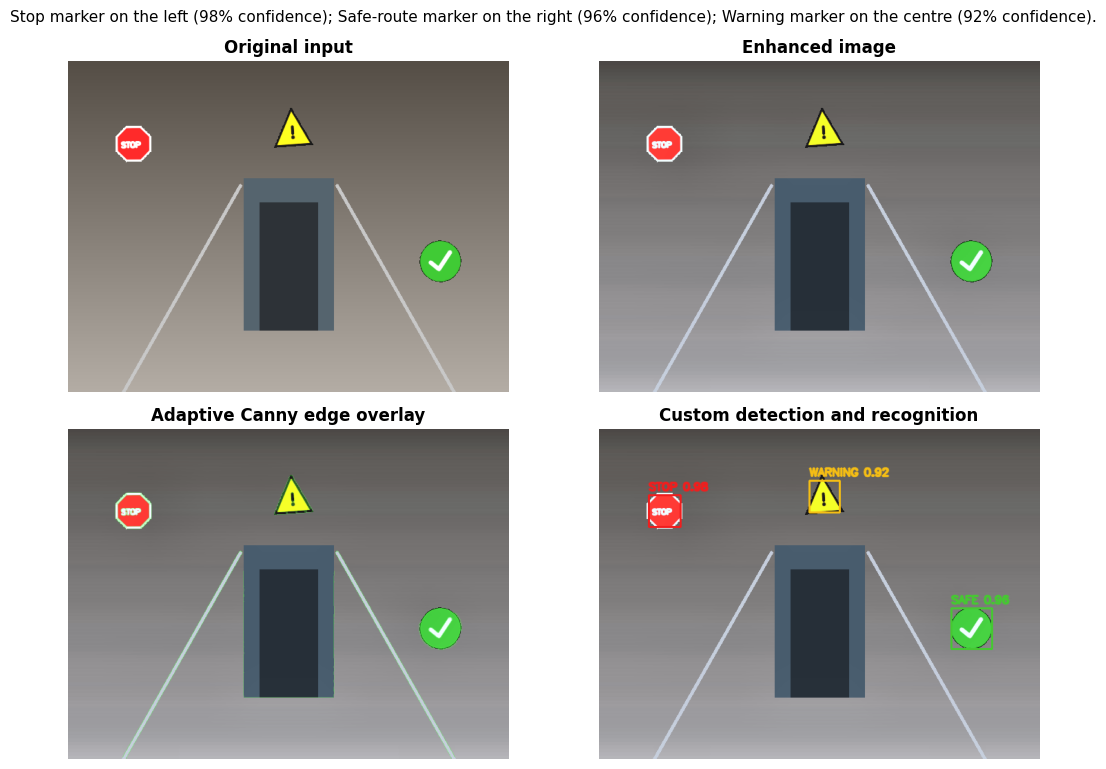

Stop marker on the left (98% confidence); Safe-route marker on the right (96% confidence); Warning marker on the centre (92% confidence).


Sample video: artifacts\sample_input_video.mp4
Processed video: artifacts\sample_processed_video.mp4
{
  "frames": 90,
  "mean_latency_ms": 16.745876668331523,
  "mean_fps": 59.71619281605727,
  "marker_detections": 135,
  "tracked_motion_regions": 136
}


,mean_latency_ms,median_latency_ms,p95_latency_ms,mean_fps,meets_10_fps_target
0,19.962686,19.70075,21.741175,50.093459,True


In [7]:
sample_scene, sample_truth = make_scene("bright", seed=54321)
sample_scene_dim, _ = make_scene("dim", seed=54322, labels=("safe", "warning"))
sample_scene_noisy, _ = make_scene("noisy", seed=54323, labels=("stop", "safe"))
sample_scene_path = ARTIFACTS / "sample_scene.png"
sample_scene_dim_path = ARTIFACTS / "sample_scene_dim.png"
sample_scene_noisy_path = ARTIFACTS / "sample_scene_noisy.png"
cv2.imwrite(str(sample_scene_path), sample_scene)
cv2.imwrite(str(sample_scene_dim_path), sample_scene_dim)
cv2.imwrite(str(sample_scene_noisy_path), sample_scene_noisy)
sample_scene_examples = [str(sample_scene_path), str(sample_scene_dim_path), str(sample_scene_noisy_path)]
sample_result = SYSTEM.process_frame(sample_scene)
cv2.imwrite(str(ARTIFACTS / "sample_annotated.png"), sample_result.annotated)
cv2.imwrite(str(ARTIFACTS / "sample_enhanced.png"), sample_result.enhanced)
cv2.imwrite(str(ARTIFACTS / "sample_edges.png"), sample_result.edge_view)

fig, axes = plt.subplots(2, 2, figsize=(11, 7.8))
views = [
    (sample_scene, "Original input"),
    (sample_result.enhanced, "Enhanced image"),
    (sample_result.edge_view, "Adaptive Canny edge overlay"),
    (sample_result.annotated, "Custom detection and recognition"),
]
for axis, (view, title) in zip(axes.ravel(), views):
    axis.imshow(cv2.cvtColor(view, cv2.COLOR_BGR2RGB))
    axis.set_title(title, fontweight="bold")
    axis.axis("off")
fig.suptitle(sample_result.summary, fontsize=11)
fig.tight_layout()
fig.savefig(ARTIFACTS / "qualitative_pipeline.png", dpi=180, bbox_inches="tight")
plt.show()
print(sample_result.summary)


def open_video_writer(path: Path, fps: float, size: tuple[int, int]) -> tuple[cv2.VideoWriter, Path]:
    writer = cv2.VideoWriter(str(path), cv2.VideoWriter_fourcc(*"mp4v"), fps, size)
    if writer.isOpened():
        return writer, path
    fallback = path.with_suffix(".avi")
    writer = cv2.VideoWriter(str(fallback), cv2.VideoWriter_fourcc(*"MJPG"), fps, size)
    if not writer.isOpened():
        raise RuntimeError("No supported video writer codec was available.")
    return writer, fallback


def create_sample_video(path: Path, seconds: int = 6, fps: int = 15) -> Path:
    width, height = 640, 480
    writer, actual_path = open_video_writer(path, fps, (width, height))
    rng = np.random.default_rng(7788)
    stop_patch, stop_mask = make_marker_patch("stop", rng, size=100, condition="bright")
    warning_patch, warning_mask = make_marker_patch("warning", rng, size=90, condition="bright")
    for frame_index in range(seconds * fps):
        frame, _ = make_scene("bright", seed=777, labels=())
        if frame_index >= fps:
            x = int(20 + (width - 140) * (frame_index - fps) / max(seconds * fps - fps - 1, 1))
            y = 95 + int(45 * math.sin(frame_index / 9))
            roi = frame[y : y + 100, x : x + 100]
            visible = stop_mask > 0
            roi[visible] = stop_patch[visible]
        if frame_index >= 2 * fps:
            x2 = 470 - int(150 * (frame_index - 2 * fps) / max(seconds * fps - 2 * fps - 1, 1))
            y2 = 285
            roi2 = frame[y2 : y2 + 90, x2 : x2 + 90]
            visible2 = warning_mask > 0
            roi2[visible2] = warning_patch[visible2]
        writer.write(frame)
    writer.release()
    return actual_path


def process_video(input_path: str | Path, output_path: str | Path, max_frames: int = 450) -> tuple[Path, dict]:
    capture = cv2.VideoCapture(str(input_path))
    if not capture.isOpened():
        raise ValueError(f"Could not open video: {input_path}")
    source_fps = float(capture.get(cv2.CAP_PROP_FPS) or 15.0)
    motion = MotionDetector()
    writer = None
    actual_output = Path(output_path)
    latencies = []
    frame_count = 0
    detection_count = 0
    motion_count = 0
    while frame_count < max_frames:
        ok, frame = capture.read()
        if not ok:
            break
        result = SYSTEM.process_frame(frame, motion=motion)
        if writer is None:
            height, width = result.annotated.shape[:2]
            writer, actual_output = open_video_writer(Path(output_path), source_fps, (width, height))
        writer.write(result.annotated)
        latencies.append(result.latency_ms)
        detection_count += len(result.detections)
        motion_count += len(result.motion_boxes)
        frame_count += 1
    capture.release()
    if writer is not None:
        writer.release()
    if frame_count == 0:
        raise ValueError("The video contained no readable frames.")
    mean_latency = float(np.mean(latencies))
    return actual_output, {
        "frames": frame_count,
        "mean_latency_ms": mean_latency,
        "mean_fps": 1000.0 / max(mean_latency, 1e-6),
        "marker_detections": detection_count,
        "tracked_motion_regions": motion_count,
    }


def place_marker(frame: np.ndarray, patch: np.ndarray, mask: np.ndarray, x: int, y: int) -> None:
    height, width = patch.shape[:2]
    roi = frame[y : y + height, x : x + width]
    visible = mask > 0
    roi[visible] = patch[visible]


def create_alternate_video(output_path: Path, condition: str, seconds: int = 6, fps: int = 15) -> Path:
    width, height = 640, 480
    writer, actual_path = open_video_writer(output_path, fps, (width, height))
    rng = np.random.default_rng(8800 if condition == "dim" else 9900)
    safe_patch, safe_mask = make_marker_patch("safe", rng, size=90, condition="bright")
    warning_patch, warning_mask = make_marker_patch("warning", rng, size=88, condition="bright")
    stop_patch, stop_mask = make_marker_patch("stop", rng, size=96, condition="bright")
    total_frames = seconds * fps
    for frame_index in range(total_frames):
        frame, _ = make_scene("bright", seed=779, labels=())
        progress = frame_index / max(total_frames - 1, 1)
        if condition == "dim":
            # The green tick travels diagonally upward while the warning marker
            # enters later from the opposite side on a shallow wave path.
            safe_x = int(25 + 500 * progress)
            safe_y = int(335 - 250 * progress)
            place_marker(frame, safe_patch, safe_mask, safe_x, safe_y)
            if frame_index >= fps:
                warning_progress = (frame_index - fps) / max(total_frames - fps - 1, 1)
                warning_x = int(515 - 420 * warning_progress)
                warning_y = int(275 + 45 * math.sin(warning_progress * 2 * math.pi))
                place_marker(frame, warning_patch, warning_mask, warning_x, warning_y)
            frame = cv2.convertScaleAbs(frame, alpha=0.55, beta=-8)
        elif condition == "blurred":
            # The stop marker follows a curved path. A safe tick enters from
            # the lower-right and crosses it on a different diagonal.
            stop_x = int(25 + 500 * progress)
            stop_y = int(85 + 75 * math.sin(progress * 2.5 * math.pi))
            place_marker(frame, stop_patch, stop_mask, stop_x, stop_y)
            if frame_index >= 2 * fps:
                safe_progress = (frame_index - 2 * fps) / max(total_frames - 2 * fps - 1, 1)
                safe_x = int(500 - 350 * safe_progress)
                safe_y = int(340 - 185 * safe_progress)
                place_marker(frame, safe_patch, safe_mask, safe_x, safe_y)
            frame = cv2.GaussianBlur(frame, (7, 7), 1.4)
        else:
            writer.release()
            raise ValueError(f"Unknown video condition: {condition}")
        writer.write(frame)
    writer.release()
    return actual_path


sample_input_video = create_sample_video(ARTIFACTS / "sample_input_video.mp4")
sample_input_video_dim = create_alternate_video(ARTIFACTS / "sample_input_video_dim.mp4", "dim")
sample_input_video_blurred = create_alternate_video(ARTIFACTS / "sample_input_video_blurred.mp4", "blurred")
sample_video_examples = [str(sample_input_video), str(sample_input_video_dim), str(sample_input_video_blurred)]
sample_output_video, video_metrics = process_video(sample_input_video, ARTIFACTS / "sample_processed_video.mp4")
print("Sample video:", sample_input_video.relative_to(ROOT))
print("Processed video:", sample_output_video.relative_to(ROOT))
print(json.dumps(video_metrics, indent=2))

# Repeatable still-frame benchmark after warm-up.
motion_benchmark = MotionDetector()
for _ in range(6):
    SYSTEM.process_frame(sample_scene, motion=motion_benchmark)
benchmark_latencies = [SYSTEM.process_frame(sample_scene, motion=motion_benchmark).latency_ms for _ in range(50)]
performance = {
    "mean_latency_ms": float(np.mean(benchmark_latencies)),
    "median_latency_ms": float(np.median(benchmark_latencies)),
    "p95_latency_ms": float(np.percentile(benchmark_latencies, 95)),
    "mean_fps": float(1000.0 / np.mean(benchmark_latencies)),
    "meets_10_fps_target": bool(1000.0 / np.mean(benchmark_latencies) >= 10.0),
}
display(pd.DataFrame([performance]))
assert performance["meets_10_fps_target"], "Performance target of 10 FPS was not met on this machine."


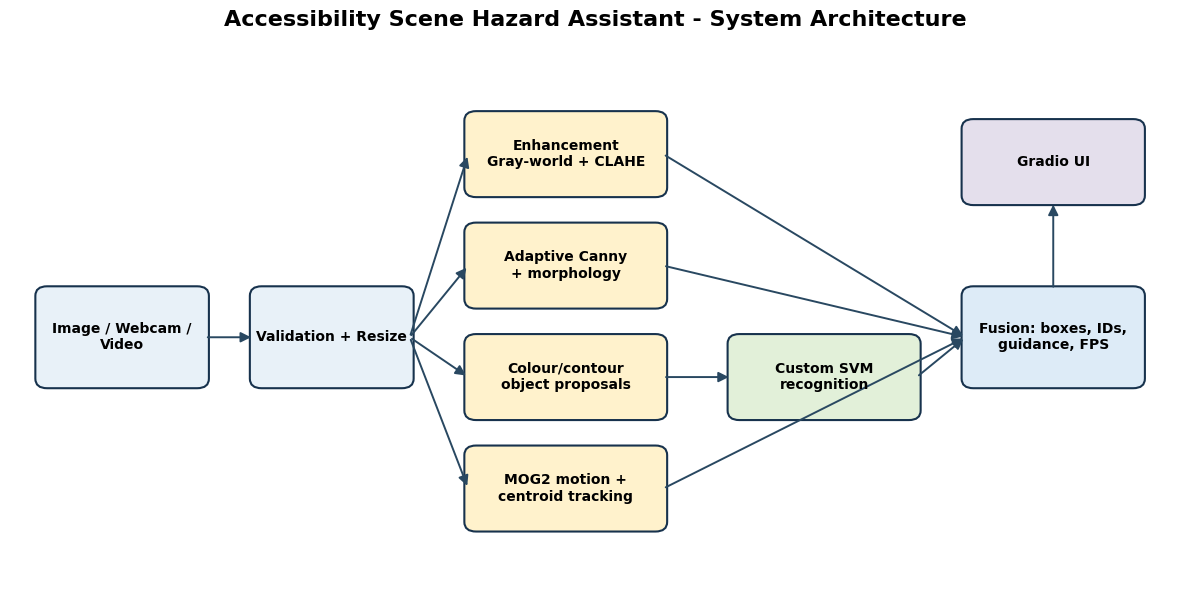

{
  "dataset": {
    "total_images": 560,
    "per_class": 140,
    "classes": [
      "stop",
      "warning",
      "safe",
      "other"
    ]
  },
  "selected_model": "SVM (RBF)",
  "held_out_accuracy": 1.0,
  "mean_detection_precision": 0.9299726589200275,
  "mean_detection_recall": 0.9464285714285714,
  "mean_detection_f1": 0.9312307608240287,
  "real_style_regression": {
    "stop": {
      "available": true,
      "detected": true,
      "confidence": 0.98,
      "box": [
        158,
        67,
        422,
        314
      ]
    },
    "safe": {
      "available": true,
      "detected": true,
      "confidence": 0.9462410900469063,
      "box": [
        0,
        0,
        640,
        620
      ]
    }
  },
  "performance": {
    "mean_latency_ms": 19.962686002254486,
    "median_latency_ms": 19.700750010088086,
    "p95_latency_ms": 21.741175034549087,
    "mean_fps": 50.09345936148397,
    "meets_10_fps_target": true
  },
  "video": {
    "frames": 90,
    "mean_late

In [8]:
# Create a clear architecture diagram for the report.
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(12, 6.2))
ax.set_xlim(0, 12)
ax.set_ylim(0, 7)
ax.axis("off")

def box(x, y, w, h, text, colour):
    patch = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.04,rounding_size=0.12", linewidth=1.5, edgecolor="#17324D", facecolor=colour)
    ax.add_patch(patch)
    ax.text(x + w / 2, y + h / 2, text, ha="center", va="center", fontsize=10, fontweight="bold", wrap=True)

def arrow(x1, y1, x2, y2):
    ax.add_patch(FancyArrowPatch((x1, y1), (x2, y2), arrowstyle="-|>", mutation_scale=15, linewidth=1.4, color="#294861"))

box(0.3, 2.7, 1.7, 1.2, "Image / Webcam /\nVideo", "#E8F1F8")
box(2.5, 2.7, 1.6, 1.2, "Validation + Resize", "#E8F1F8")
box(4.7, 5.1, 2.0, 1.0, "Enhancement\nGray-world + CLAHE", "#FFF2CC")
box(4.7, 3.7, 2.0, 1.0, "Adaptive Canny\n+ morphology", "#FFF2CC")
box(4.7, 2.3, 2.0, 1.0, "Colour/contour\nobject proposals", "#FFF2CC")
box(4.7, 0.9, 2.0, 1.0, "MOG2 motion +\ncentroid tracking", "#FFF2CC")
box(7.4, 2.3, 1.9, 1.0, "Custom SVM\nrecognition", "#E2F0D9")
box(9.8, 2.7, 1.8, 1.2, "Fusion: boxes, IDs,\nguidance, FPS", "#DDEBF7")
box(9.8, 5.0, 1.8, 1.0, "Gradio UI", "#E4DFEC")
arrow(2.0, 3.3, 2.5, 3.3)
for y in [5.6, 4.2, 2.8, 1.4]:
    arrow(4.1, 3.3, 4.7, y)
arrow(6.7, 2.8, 7.4, 2.8)
for y in [5.6, 4.2, 2.8, 1.4]:
    arrow(6.7 if y != 2.8 else 9.3, y, 9.8, 3.3)
arrow(10.7, 3.9, 10.7, 5.0)
ax.set_title("Accessibility Scene Hazard Assistant - System Architecture", fontsize=16, fontweight="bold", pad=12)
fig.tight_layout()
fig.savefig(ARTIFACTS / "architecture_diagram.png", dpi=180, bbox_inches="tight")
plt.show()

overall_precision = float(detection_robustness.precision.mean())
overall_recall = float(detection_robustness.recall.mean())
overall_f1 = float(detection_robustness.f1.mean())
metrics = {
    "dataset": {"total_images": len(images), "per_class": len(images) // len(LABELS), "classes": LABELS},
    "selected_model": selected_model_name,
    "held_out_accuracy": test_accuracy,
    "mean_detection_precision": overall_precision,
    "mean_detection_recall": overall_recall,
    "mean_detection_f1": overall_f1,
    "real_style_regression": real_style_results,
    "performance": performance,
    "video": video_metrics,
    "artifacts": {
        "sample_input_video": str(sample_input_video.relative_to(ROOT)),
        "sample_output_video": str(sample_output_video.relative_to(ROOT)),
    },
}
(ARTIFACTS / "metrics.json").write_text(json.dumps(metrics, indent=2), encoding="utf-8")
print(json.dumps(metrics, indent=2))


## 6. Required two-to-three-minute demonstration video

The following cell creates a 2 minute 5 second MP4 from the actual architecture, qualitative output, processed motion/tracking video, and measured results. It is a reliable backup for technical failure and can also be submitted as the required demonstration video. The live defence must still be performed by the group.


In [9]:
def fit_image_on_canvas(image_bgr: np.ndarray, canvas: np.ndarray, margin: int = 45) -> np.ndarray:
    available_w, available_h = canvas.shape[1] - 2 * margin, canvas.shape[0] - 2 * margin
    scale = min(available_w / image_bgr.shape[1], available_h / image_bgr.shape[0])
    resized = cv2.resize(image_bgr, (int(image_bgr.shape[1] * scale), int(image_bgr.shape[0] * scale)), interpolation=cv2.INTER_AREA)
    y = (canvas.shape[0] - resized.shape[0]) // 2
    x = (canvas.shape[1] - resized.shape[1]) // 2
    canvas[y : y + resized.shape[0], x : x + resized.shape[1]] = resized
    return canvas


def title_card(title: str, lines: list[str], width: int = 1280, height: int = 720) -> np.ndarray:
    canvas = np.full((height, width, 3), (35, 51, 68), np.uint8)
    cv2.rectangle(canvas, (0, 0), (width, 18), (55, 160, 210), -1)
    cv2.putText(canvas, title, (70, 120), cv2.FONT_HERSHEY_DUPLEX, 1.35, (245, 248, 250), 2, cv2.LINE_AA)
    y = 205
    for line in lines:
        wrapped = textwrap.wrap(line, width=72) or [""]
        for part in wrapped:
            cv2.putText(canvas, part, (85, y), cv2.FONT_HERSHEY_SIMPLEX, 0.72, (225, 232, 238), 2, cv2.LINE_AA)
            y += 42
        y += 10
    cv2.putText(canvas, "CSCI435 | Accessibility Scene Hazard Assistant", (70, height - 45), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (155, 190, 215), 1, cv2.LINE_AA)
    return canvas


def build_demonstration_video(output_path: Path, fps: int = 10) -> Path:
    width, height = 1280, 720
    writer, actual_path = open_video_writer(output_path, fps, (width, height))

    def add_static(frame: np.ndarray, seconds: int):
        for _ in range(seconds * fps):
            writer.write(frame)

    add_static(title_card("Accessibility Scene Hazard Assistant", ["Integrated image enhancement, edge detection, object detection and recognition, motion detection, and tracking.", "Inputs: image/webcam and uploaded video.", "All evidence in this video was generated by the submitted notebook."]), 12)

    architecture = cv2.imread(str(ARTIFACTS / "architecture_diagram.png"))
    add_static(fit_image_on_canvas(architecture, np.full((height, width, 3), 245, np.uint8)), 18)

    qualitative = cv2.imread(str(ARTIFACTS / "qualitative_pipeline.png"))
    add_static(fit_image_on_canvas(qualitative, np.full((height, width, 3), 248, np.uint8)), 25)

    capture = cv2.VideoCapture(str(sample_output_video))
    processed_frames = []
    while True:
        ok, frame = capture.read()
        if not ok:
            break
        processed_frames.append(fit_image_on_canvas(frame, np.full((height, width, 3), (24, 34, 43), np.uint8)))
    capture.release()
    for index in range(30 * fps):
        frame = processed_frames[index % len(processed_frames)].copy()
        cv2.putText(frame, "Video mode: MOG2 motion + persistent track IDs", (55, 55), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (240, 245, 248), 2, cv2.LINE_AA)
        writer.write(frame)

    result_lines = [
        f"Custom dataset: {len(images)} labelled synthetic images across four classes.",
        f"Selected model: {selected_model_name}; held-out recognition accuracy: {test_accuracy:.1%}.",
        f"Mean end-to-end detection precision / recall / F1: {overall_precision:.1%} / {overall_recall:.1%} / {overall_f1:.1%}.",
        f"CPU benchmark: {performance['mean_fps']:.1f} FPS and {performance['mean_latency_ms']:.1f} ms mean latency.",
        f"Rubric target of 10 FPS: {'MET' if performance['meets_10_fps_target'] else 'NOT MET'}.",
    ]
    add_static(title_card("Quantitative results", result_lines), 20)
    add_static(title_card("Robustness and critical analysis", ["Evaluated under bright, dim, rotated, blurred, noisy, occluded, and cluttered conditions.", "Graceful behaviour is tested for blank, tiny, and unreadable inputs.", "Main limitation: synthetic markers and colour proposals do not represent all real-world hazards; a consented real dataset is required before deployment."]), 12)
    add_static(title_card("Conclusion and next steps", ["One deployable interface integrates six computer-vision operations and two input modalities.", "Next: real labelled data, a modern object detector, calibrated depth, audio/haptic feedback, mobile deployment, and user testing.", "The live Gradio demonstration remains the primary Week 11 defence; this 2:05 video is the required submission and backup."]), 8)
    writer.release()
    return actual_path


demonstration_video = build_demonstration_video(ARTIFACTS / "CSCI435_Demonstration_Video.mp4")
duration = cv2.VideoCapture(str(demonstration_video))
frame_total = int(duration.get(cv2.CAP_PROP_FRAME_COUNT))
video_fps = float(duration.get(cv2.CAP_PROP_FPS))
duration.release()
duration_seconds = frame_total / max(video_fps, 1e-6)
assert 120 <= duration_seconds <= 180, f"Demo duration must be 2-3 minutes, got {duration_seconds:.1f}s"
print(f"Created required demonstration video: {demonstration_video.relative_to(ROOT)} ({duration_seconds:.1f} seconds)")


Created required demonstration video: artifacts\CSCI435_Demonstration_Video.mp4 (125.0 seconds)


## 7. Gradio web application

The interface presents the integrated results rather than isolated scripts. Image mode accepts upload or webcam capture. Video mode accepts an uploaded file and returns a fully annotated video plus measured performance. The final cell does not use a public share link; everything runs locally.


In [10]:
def bgr_to_rgb(image: np.ndarray) -> np.ndarray:
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


def ui_process_image(image_rgb: np.ndarray | None):
    if image_rgb is None:
        raise gr.Error("Upload an image or capture a webcam frame first.")
    image = np.asarray(image_rgb)
    if image.dtype != np.uint8:
        image = np.clip(image * 255 if image.max() <= 1.0 else image, 0, 255).astype(np.uint8)
    if image.ndim == 2:
        frame_bgr = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
    elif image.shape[2] == 4:
        frame_bgr = cv2.cvtColor(image, cv2.COLOR_RGBA2BGR)
    else:
        frame_bgr = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
    try:
        result = SYSTEM.process_frame(frame_bgr)
    except ValueError as exc:
        raise gr.Error(str(exc)) from exc
    metrics_text = f"**Latency:** {result.latency_ms:.1f} ms  |  **Estimated throughput:** {result.fps:.1f} FPS  |  **Markers:** {len(result.detections)}"
    return bgr_to_rgb(result.annotated), bgr_to_rgb(result.enhanced), bgr_to_rgb(result.edge_view), result.summary, metrics_text


def ui_process_video(video_path: str | None):
    if not video_path:
        raise gr.Error("Upload a readable video first.")
    output = ARTIFACTS / f"ui_processed_{int(time.time())}.mp4"
    try:
        actual_output, result = process_video(video_path, output)
    except (ValueError, RuntimeError) as exc:
        raise gr.Error(str(exc)) from exc
    metrics_text = (
        f"Processed {result['frames']} frames. Mean latency: {result['mean_latency_ms']:.1f} ms; "
        f"estimated throughput: {result['mean_fps']:.1f} FPS; marker detections: {result['marker_detections']}; "
        f"tracked motion regions: {result['tracked_motion_regions']}."
    )
    return str(actual_output), metrics_text


def build_gradio_app():
    with gr.Blocks(title="CSCI435 Accessibility Scene Hazard Assistant", theme=gr.themes.Soft(primary_hue="blue")) as demo:
        gr.Markdown(
            "# Accessibility Scene Hazard Assistant\n"
            "Upload an image/video or use a webcam capture. The system enhances the scene, highlights edges, "
            "recognises custom markers, detects motion, and reports latency/FPS. Red = stop, yellow = warning, green = safe route."
        )
        with gr.Tab("Image / Webcam"):
            with gr.Row():
                image_input = gr.Image(label="Input", sources=["upload", "webcam"], type="numpy")
                annotated_output = gr.Image(label="Integrated annotated result", type="numpy")
            process_image_button = gr.Button("Analyse scene", variant="primary")
            guidance_output = gr.Textbox(label="Scene guidance", lines=2)
            image_metrics = gr.Markdown()
            with gr.Row():
                enhanced_output = gr.Image(label="Enhanced view", type="numpy")
                edge_output = gr.Image(label="Edge view", type="numpy")
            gr.Examples(examples=[[path] for path in sample_scene_examples], inputs=[image_input], label="Reliable defence examples: bright, dim, and noisy")
            process_image_button.click(
                ui_process_image,
                inputs=[image_input],
                outputs=[annotated_output, enhanced_output, edge_output, guidance_output, image_metrics],
            )
        with gr.Tab("Video"):
            gr.Markdown("Upload a video to apply the same image pipeline plus MOG2 motion detection and centroid tracking.")
            video_input = gr.Video(label="Input video")
            process_video_button = gr.Button("Process video", variant="primary")
            video_output = gr.Video(label="Annotated video")
            video_metrics_output = gr.Textbox(label="Video metrics", lines=3)
            gr.Examples(examples=[[path] for path in sample_video_examples], inputs=[video_input], label="Generated motion examples: bright, dim, and blurred")
            process_video_button.click(ui_process_video, inputs=[video_input], outputs=[video_output, video_metrics_output])
        with gr.Accordion("Model and limitations", open=False):
            gr.Markdown(
                f"**Model:** {selected_model_name}, trained on {len(images)} custom synthetic crops.  \n"
                f"**Held-out accuracy:** {test_accuracy:.1%}.  \n"
                "**Limitation:** this proof-of-concept uses coloured synthetic markers; it must not be treated as a safety device "
                "without real-world data, calibration, and user testing."
            )
    return demo


APP = build_gradio_app()
if os.environ.get("CSCI435_QA") == "1":
    print("QA mode: Gradio interface constructed; server launch skipped.")
else:
    standalone = os.environ.get("CSCI435_STANDALONE") == "1"
    APP.launch(server_name="127.0.0.1", server_port=7860, share=False, inline=not standalone, prevent_thread_lock=not standalone)


QA mode: Gradio interface constructed; server launch skipped.


## 8. Final verification summary

The executed notebook should show: a generated dataset, model-comparison table, confusion matrix, condition-wise robustness table, qualitative outputs, successful assertions, sample videos, architecture diagram, performance above the 10 FPS rubric threshold, and a constructed/available Gradio interface. The report uses these generated results directly.
